# Прогноз согласия клиента на срочный вклад

Источник данных: телефонные маркетинговые кампании португальского банка (Moro et al., 2011).

Файл bank.arff содержит 45 211 записей о звонках клиентам за период с мая 2008 по ноябрь 2010. Данные упорядочены по дате. Пропусков нет.

### Постановка задачи

Требуется решить задачу бинарной классификации: по сведениям о клиенте и параметрах кампании определить, согласится ли клиент на открытие срочного вклада.

Целевая переменная y принимает значения yes при согласии и no при отказе.

Признаки:

1. age - возраст клиента в годах
2. job - род занятий
3. marital - семейное положение
4. education - образование
5. default - наличие просрочки по кредиту
6. balance - годовой баланс на счёте в евро
7. housing - наличие ипотеки
8. loan - наличие персонального кредита
9. contact - канал связи
10. day - день месяца последнего контакта
11. month - месяц последнего контакта
12. duration - длительность последнего звонка в секундах
13. campaign - число контактов с клиентом в текущей кампании
14. pdays - число дней с момента прошлого контакта
15. previous - число контактов с клиентом до текущей кампании
16. poutcome - исход предыдущей кампании


## 1. Загрузка данных

Файл bank.arff загружается через scipy.io.arff. Колонки V1–V16 переименовываются в осмысленные имена. Типы данных приводятся к формату, удобному для дальнейшей обработки в pandas.


In [47]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


In [48]:
def resolve_data_path(filename: str = 'bank.arff') -> Path:
    candidates = []

    for key in ('__vsc_ipynb_file__', '__file__'):
        ref = globals().get(key)
        if ref:
            candidates.append(Path(ref).resolve().parent / filename)

    cwd = Path.cwd()
    candidates.extend([cwd / filename, cwd / 'project' / filename])

    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / filename)
        candidates.append(parent / 'project' / filename)

    checked = []
    seen = set()
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except OSError:
            continue
        if resolved in seen:
            continue
        seen.add(resolved)
        checked.append(resolved)
        if resolved.exists():
            return resolved

    raise FileNotFoundError(
        f'Файл {filename} не найден. Текущая папка: {cwd}. '
        'Проверьте, что в репозитории есть project/bank.arff.'
    )


DATA_PATH = resolve_data_path()
print(f'Файл данных: {DATA_PATH}')

COLUMN_NAMES = {
    'V1': 'age',
    'V2': 'job',
    'V3': 'marital',
    'V4': 'education',
    'V5': 'default',
    'V6': 'balance',
    'V7': 'housing',
    'V8': 'loan',
    'V9': 'contact',
    'V10': 'day',
    'V11': 'month',
    'V12': 'duration',
    'V13': 'campaign',
    'V14': 'pdays',
    'V15': 'previous',
    'V16': 'poutcome',
    'Class': 'y',
}

CATEGORICAL_COLUMNS = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome', 'y',
]

raw_data, _ = arff.loadarff(DATA_PATH)
df = pd.DataFrame(raw_data)

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode('utf-8')

df = df.rename(columns=COLUMN_NAMES)
df['y'] = df['y'].map({'1': 'no', '2': 'yes'})

for col in CATEGORICAL_COLUMNS:
    df[col] = df[col].astype('category')

INTEGER_COLUMNS = ['age', 'day', 'duration', 'campaign', 'pdays', 'previous']
df[INTEGER_COLUMNS] = df[INTEGER_COLUMNS].astype('int64')
df['balance'] = df['balance'].astype('int64')


Файл данных: /Users/polinapuhova/IdeaProjects/ML-Basic/project/bank.arff


In [49]:
print(f'Загружено {df.shape[0]} строк и {df.shape[1]} колонок')
print(f'Доля согласий на срочный вклад: {(df["y"] == "yes").mean():.1%}')

df.head()


Загружено 45211 строк и 17 колонок
Доля согласий на срочный вклад: 11.7%


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [50]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  category
dtypes: category(10), int64(7)
memory usage: 2.8 MB


## 2. Первичный анализ данных

На данном этапе исследуется баланс классов, распределения всех признаков и их связь с целевой переменной y. Учитывается хронологический порядок записей при последующем разделении выборок.

Строятся графики распределения целевой переменной, гистограммы числовых признаков, частоты категориальных значений, доли согласий по категориям, распределения числовых признаков по классам, матрица корреляций, диаграммы рассеяния и boxplot-ы без выбросов для наглядного сравнения классов.


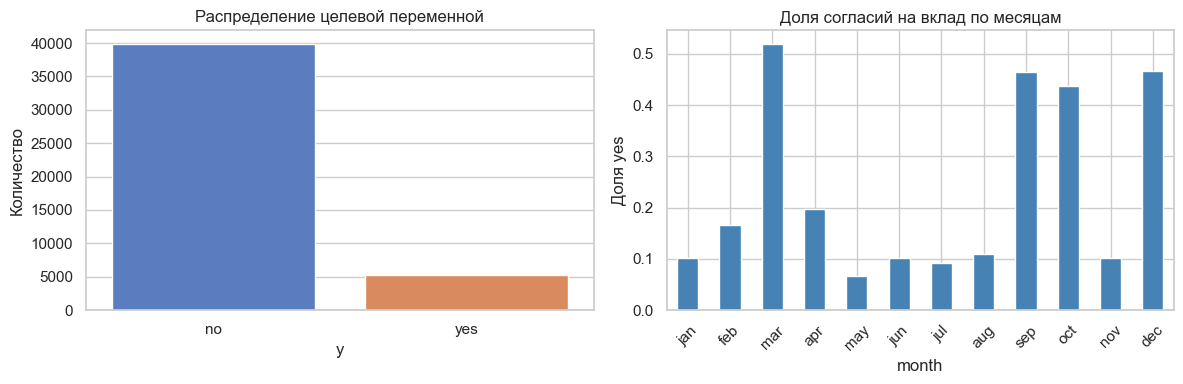

Пропуски:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Дубликаты: 0

Числовые признаки: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [51]:
cat_cols = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome',
]
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_counts = df['y'].value_counts()
sns.barplot(x=y_counts.index.astype(str), y=y_counts.values, ax=axes[0], palette='muted')
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Количество')

conversion_by_month = df.groupby('month', observed=True)['y'].apply(lambda s: (s == 'yes').mean())
conversion_by_month = conversion_by_month.reindex(month_order)
conversion_by_month.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Доля согласий на вклад по месяцам')
axes[1].set_xlabel('month')
axes[1].set_ylabel('Доля yes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Пропуски:')
print(df.isna().sum())
print('\nДубликаты:', df.duplicated().sum())
print('\nЧисловые признаки:', num_cols)
print('Категориальные признаки:', cat_cols)


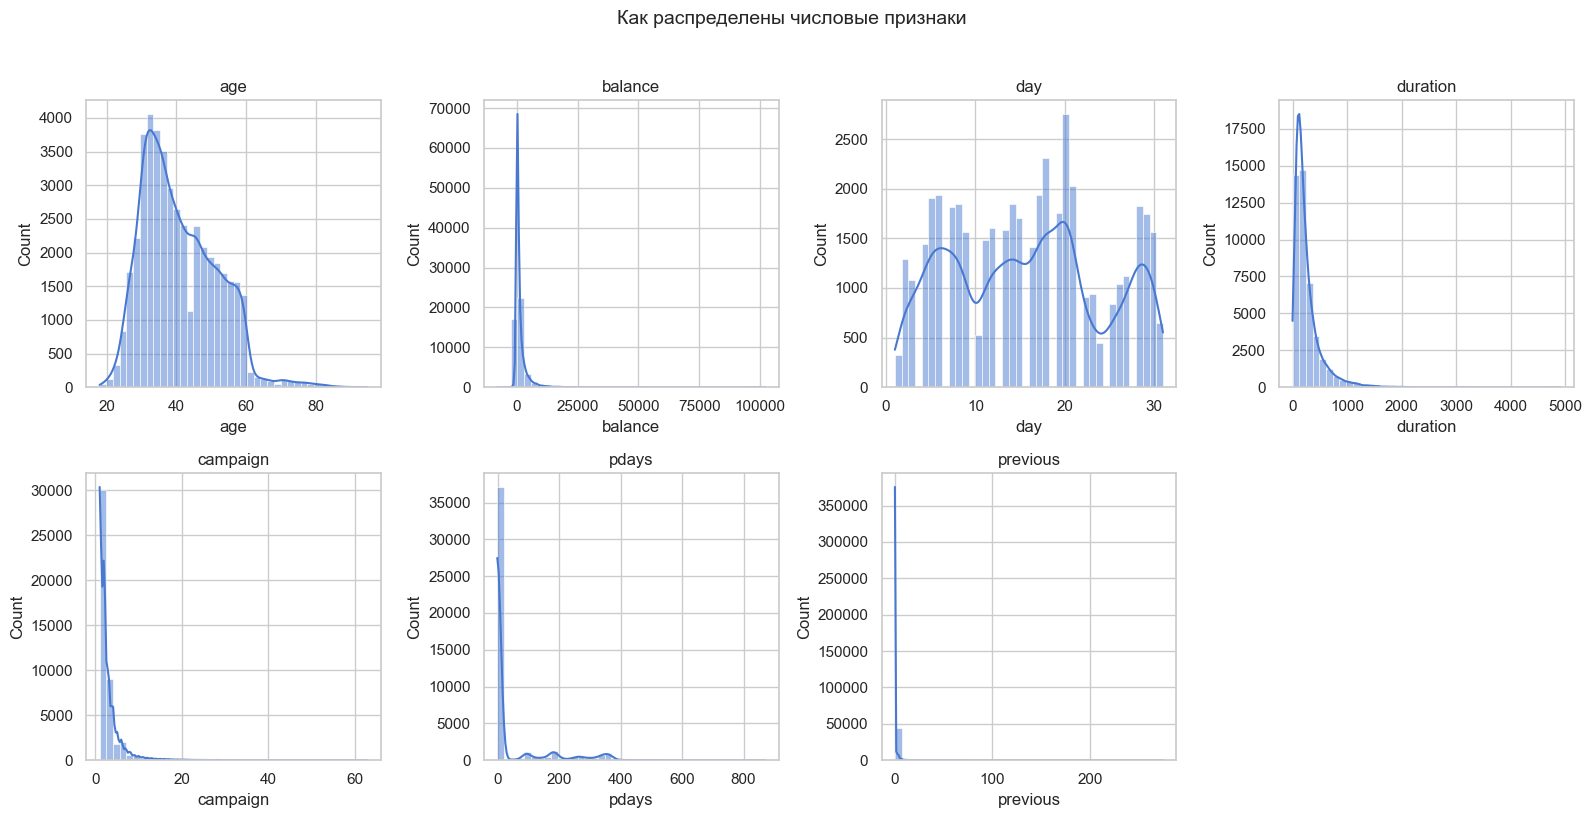

In [52]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)

axes.ravel()[-1].axis('off')
plt.suptitle('Как распределены числовые признаки', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


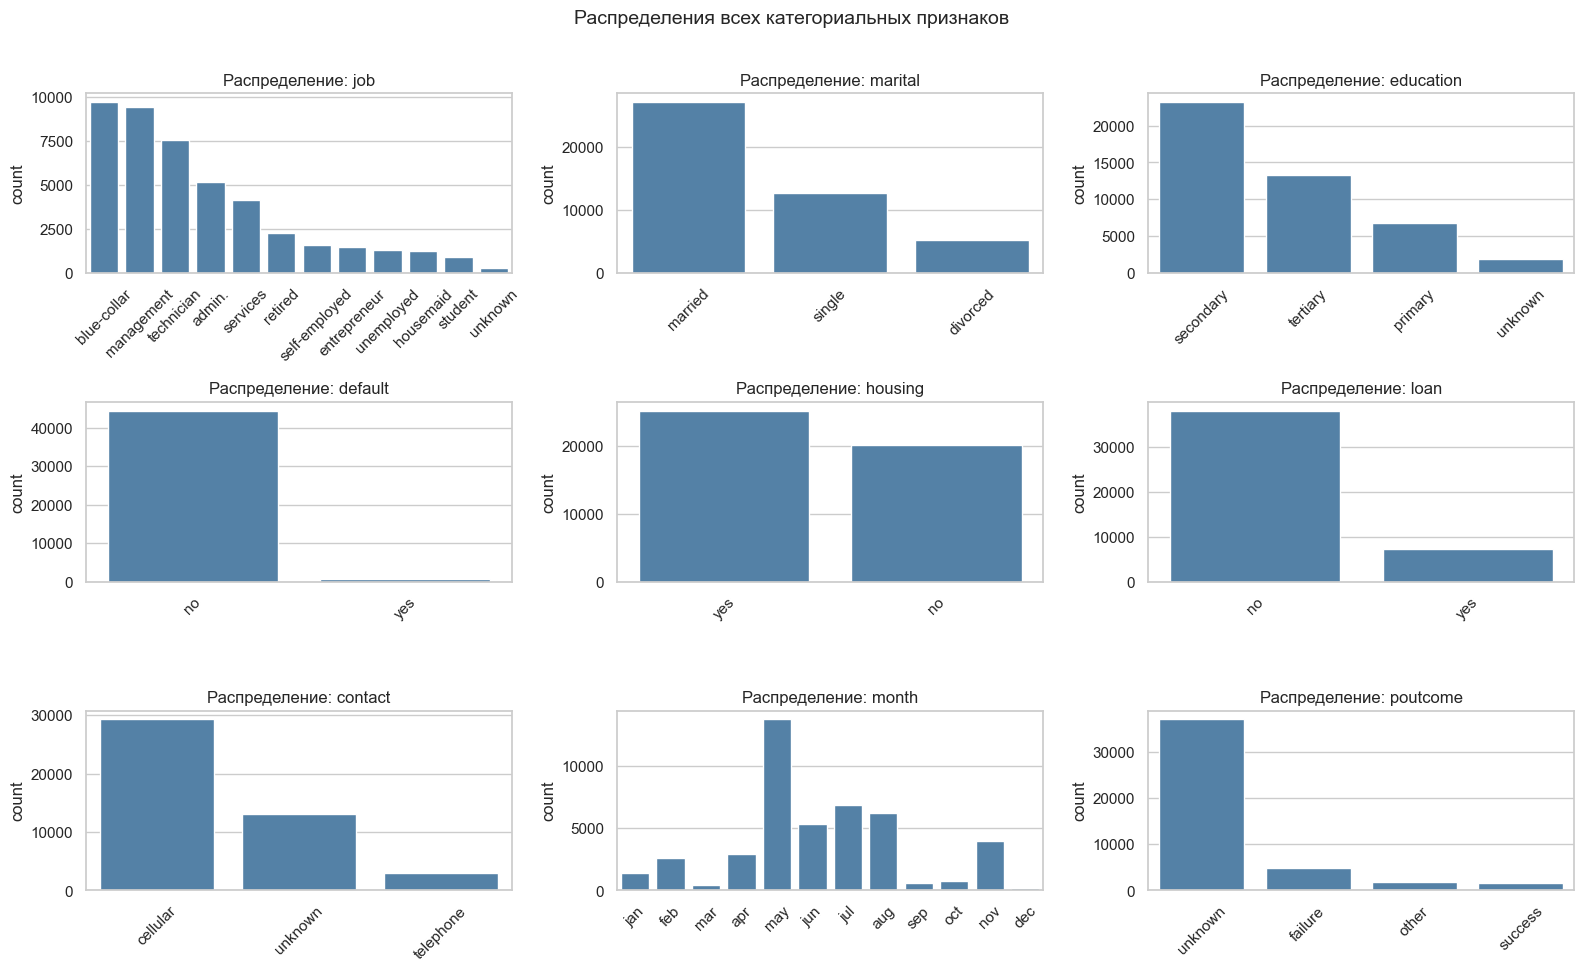

In [53]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    order = month_order if col == 'month' else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, color='steelblue')
    ax.set_title(f'Распределение: {col}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

for ax in axes[len(cat_cols):]:
    ax.axis('off')

plt.suptitle('Распределения всех категориальных признаков', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


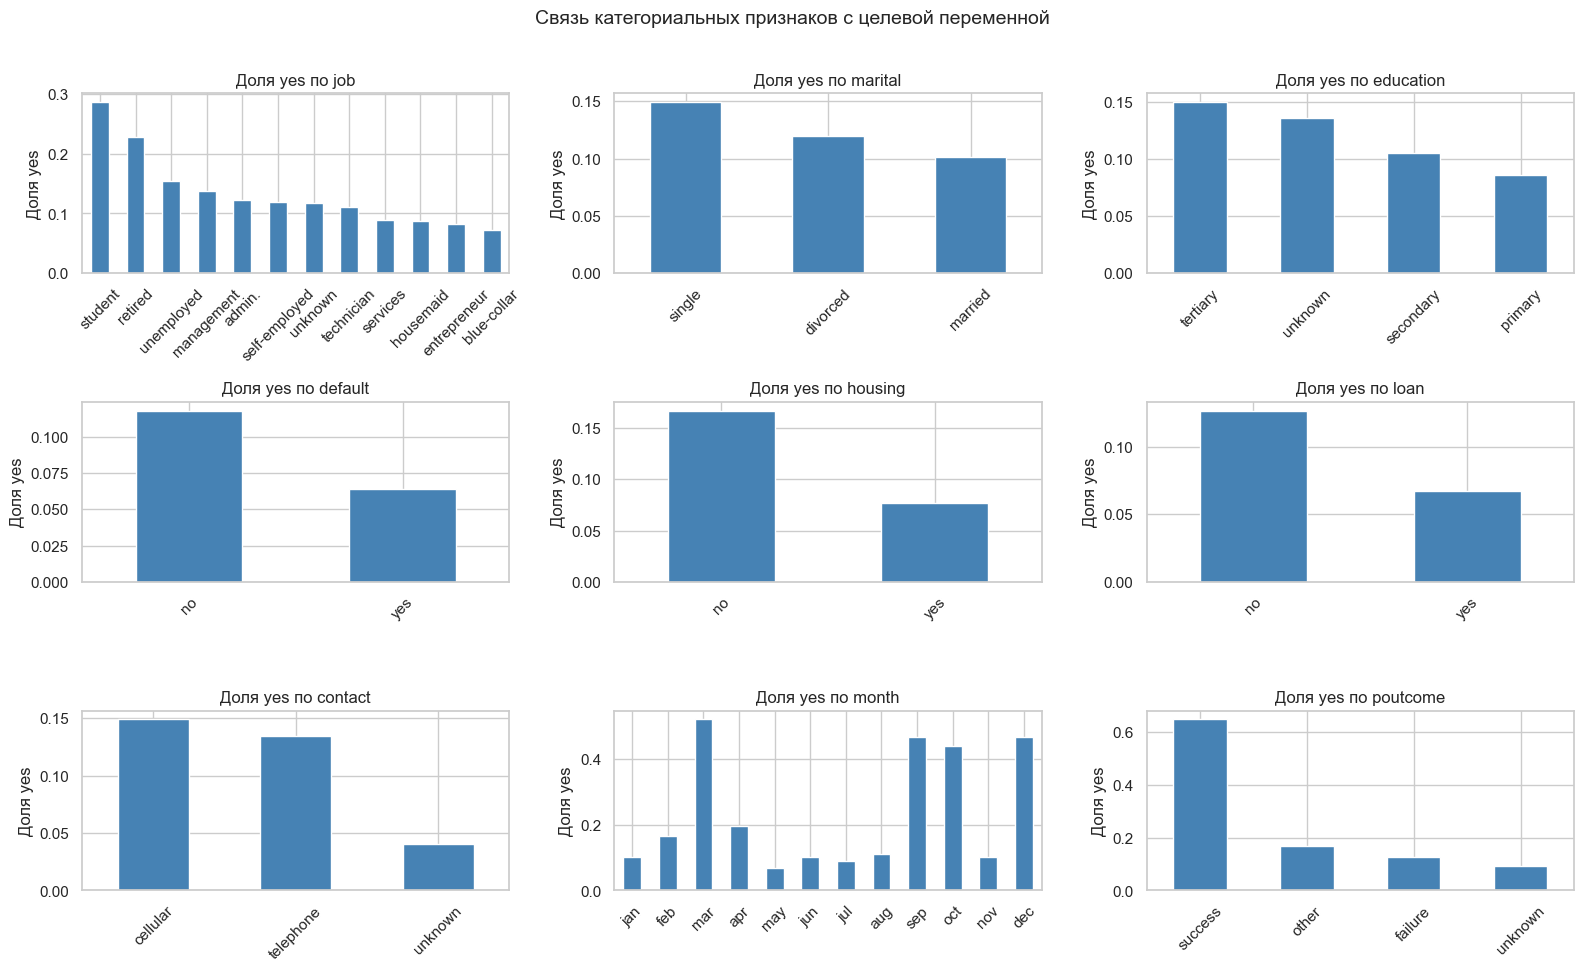

In [54]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col, observed=True)['y'].apply(lambda s: (s == 'yes').mean())
    if col == 'month':
        rates = rates.reindex(month_order)
    else:
        rates = rates.sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Доля yes по {col}')
    ax.set_ylabel('Доля yes')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.axis('off')

plt.suptitle('Связь категориальных признаков с целевой переменной', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


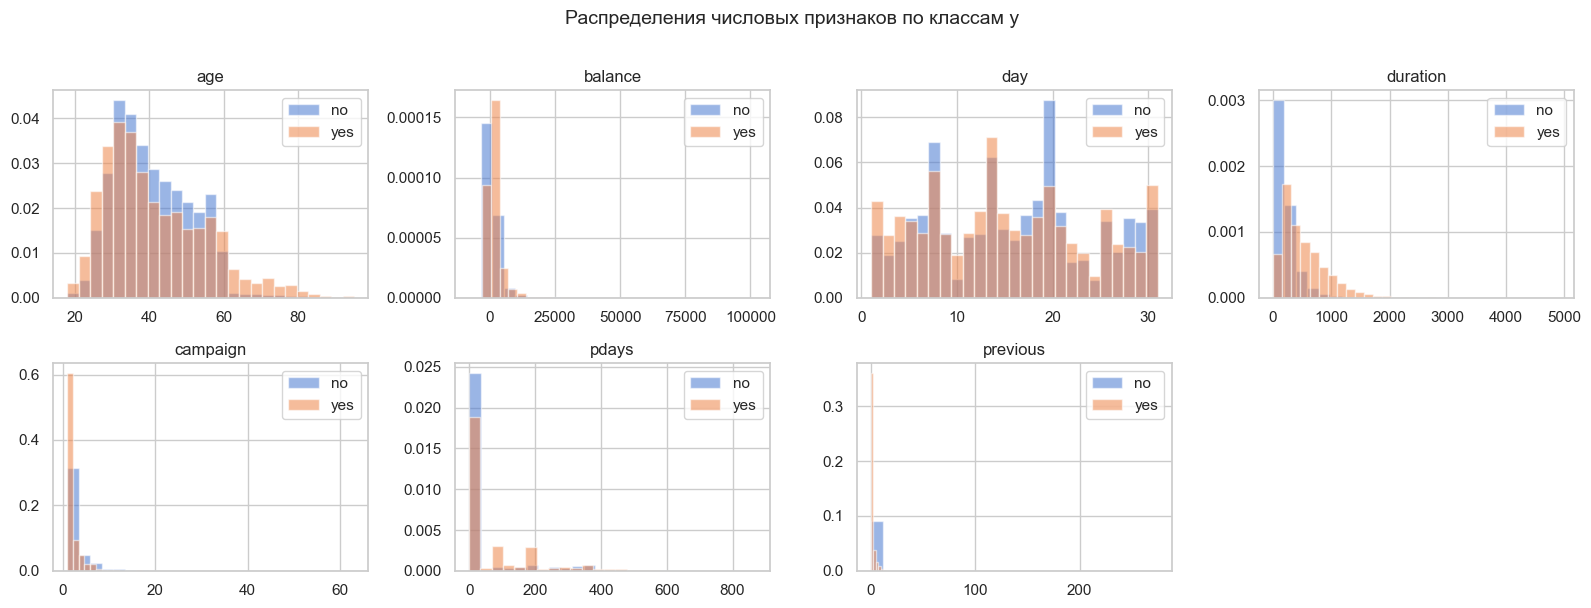

In [55]:
n_cols_grid = 4
n_rows = int(np.ceil(len(num_cols) / n_cols_grid))
fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(16, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for label, group in df.groupby('y', observed=True):
        ax.hist(group[col], bins=25, alpha=0.55, label=str(label), density=True)
    ax.set_title(col)
    ax.legend()

for ax in axes[len(num_cols):]:
    ax.axis('off')

plt.suptitle('Распределения числовых признаков по классам y', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


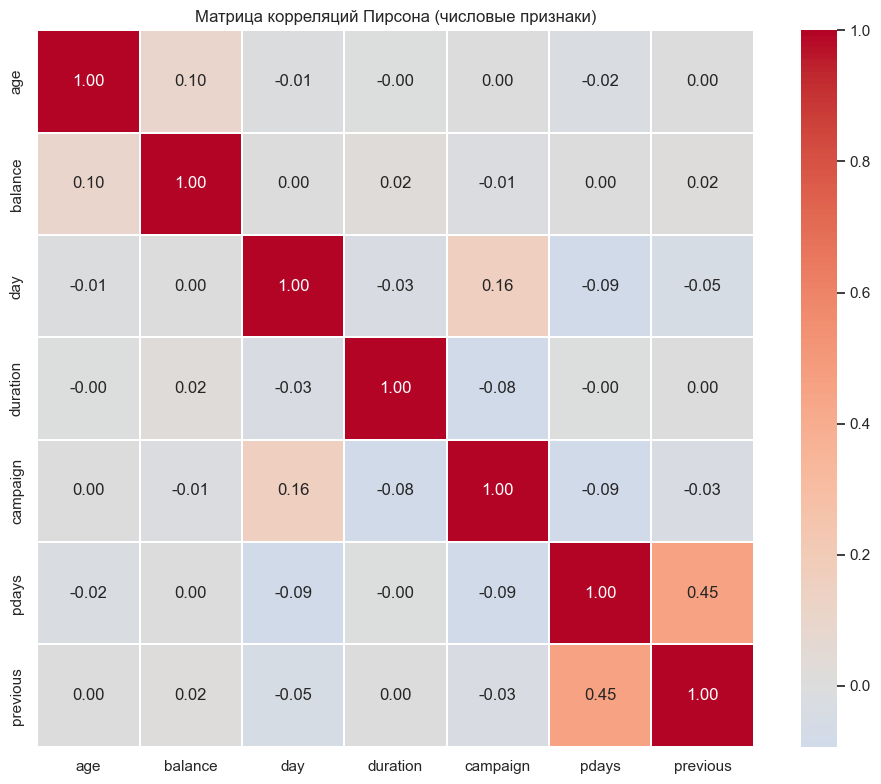

,feature_1,feature_2,correlation
41,pdays,previous,0.454820
18,day,campaign,0.162490
1,age,balance,0.097783
19,day,pdays,-0.093044
33,campaign,pdays,-0.088628
25,duration,campaign,-0.084570
20,day,previous,-0.051710
34,campaign,previous,-0.032855
17,day,duration,-0.030206
5,age,pdays,-0.023758


In [56]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.3)
plt.title('Матрица корреляций Пирсона (числовые признаки)')
plt.tight_layout()
plt.show()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
strong_corr = corr_pairs.reindex(corr_pairs['correlation'].abs().sort_values(ascending=False).index)
strong_corr.head(10)


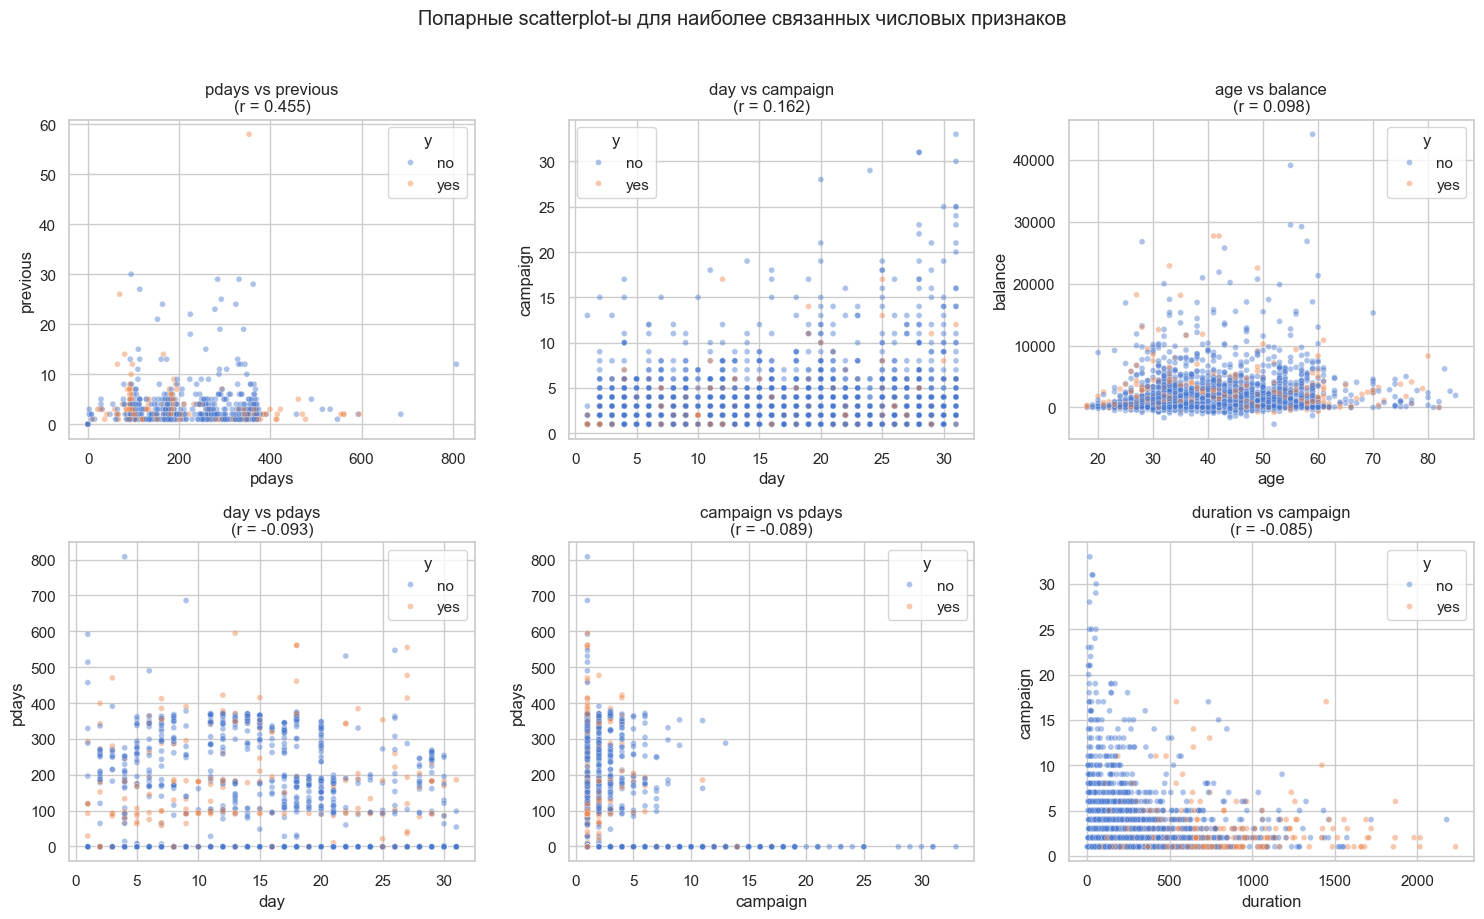

In [57]:
top_pairs = strong_corr.head(6)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

sample = df.sample(n=min(4000, len(df)), random_state=RANDOM_STATE)

for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    f1, f2 = row['feature_1'], row['feature_2']
    sns.scatterplot(data=sample, x=f1, y=f2, hue='y', alpha=0.45, s=18, ax=ax)
    ax.set_title(f'{f1} vs {f2}\n(r = {row["correlation"]:.3f})')

plt.suptitle('Попарные scatterplot-ы для наиболее связанных числовых признаков', y=1.02)
plt.tight_layout()
plt.show()


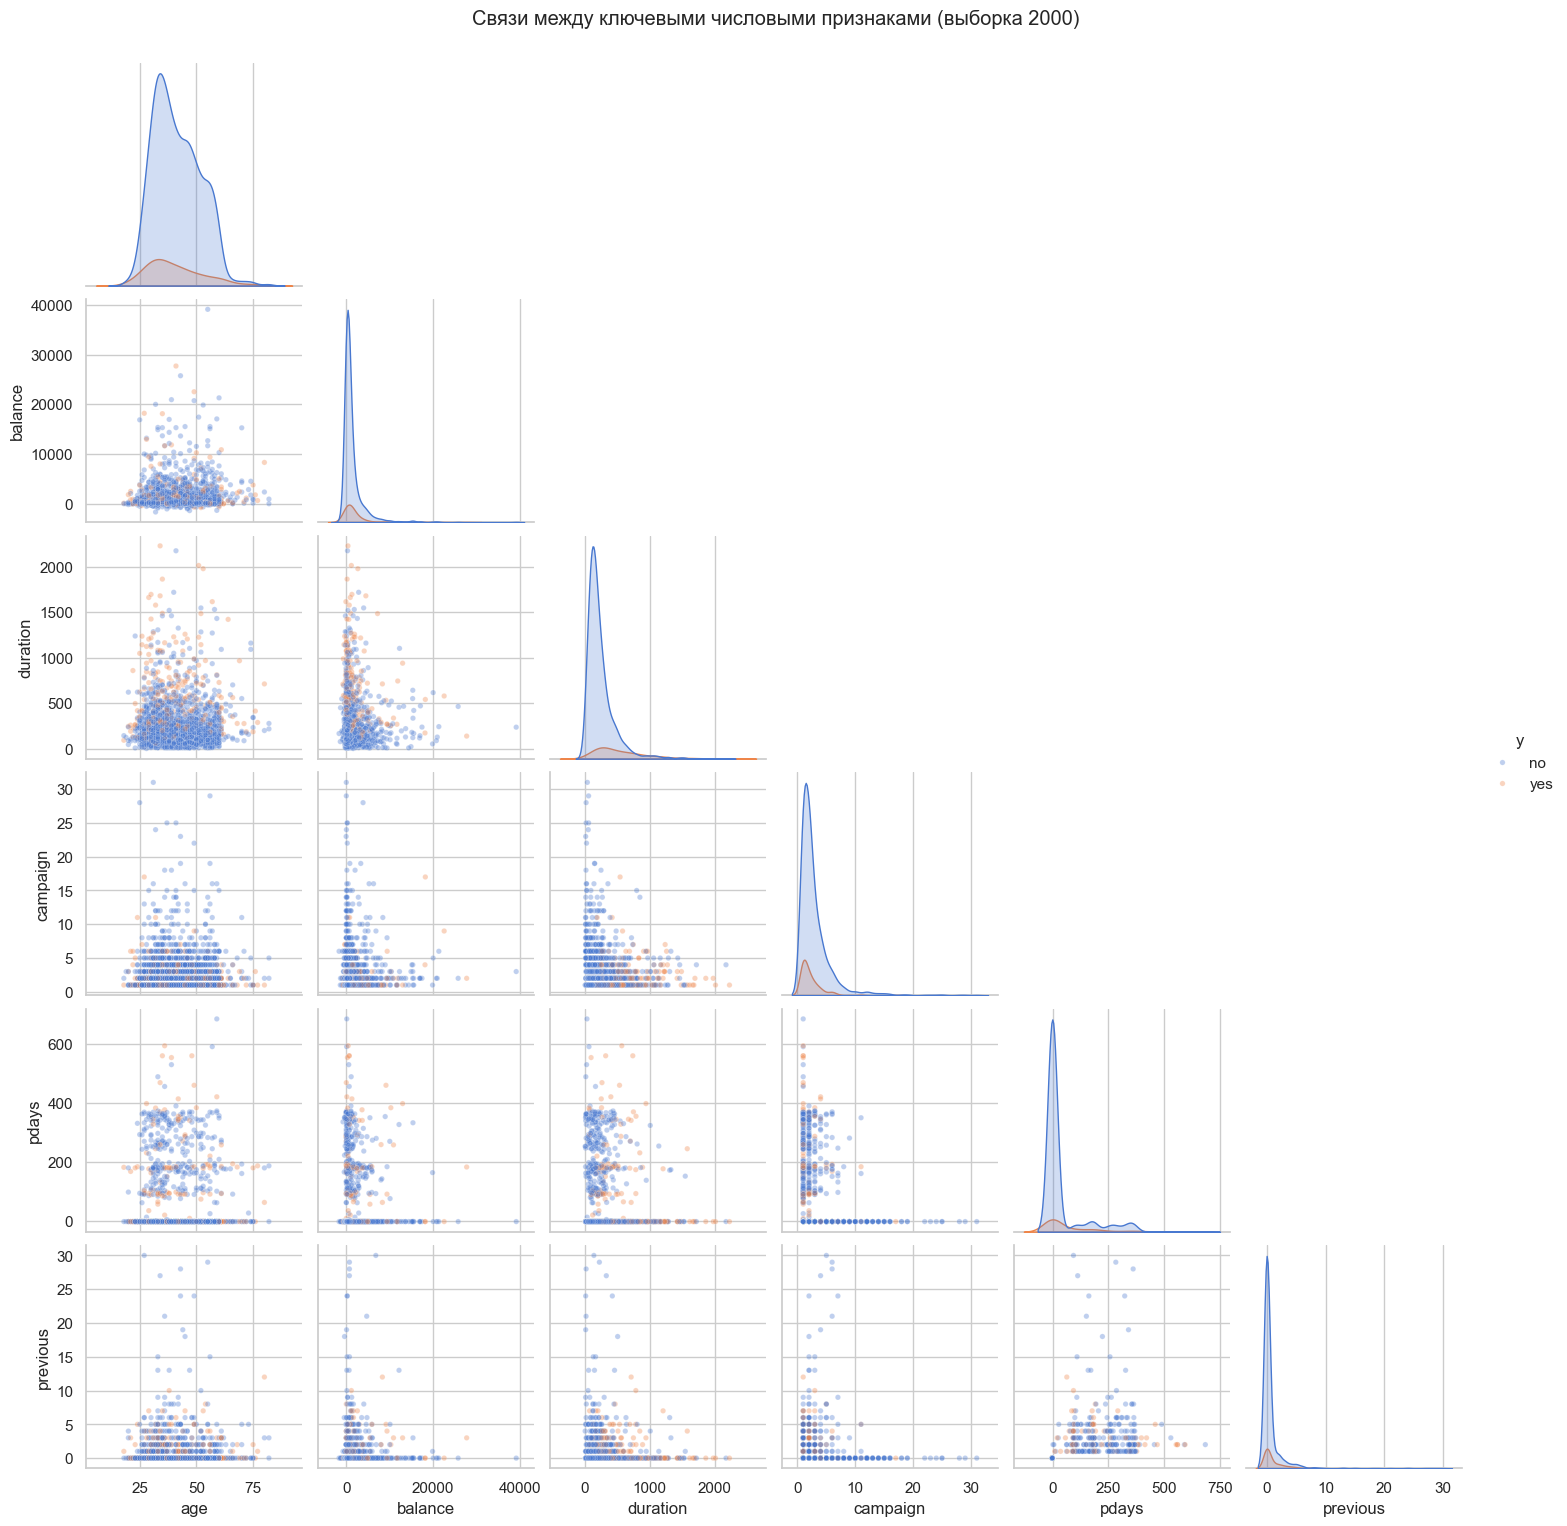

In [58]:
pair_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'y']
sample_for_pair = df[pair_cols].sample(n=2000, random_state=RANDOM_STATE)

g = sns.pairplot(
    sample_for_pair,
    hue='y',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.35, 's': 15},
)
g.fig.suptitle('Связи между ключевыми числовыми признаками (выборка 2000)', y=1.02)
plt.show()


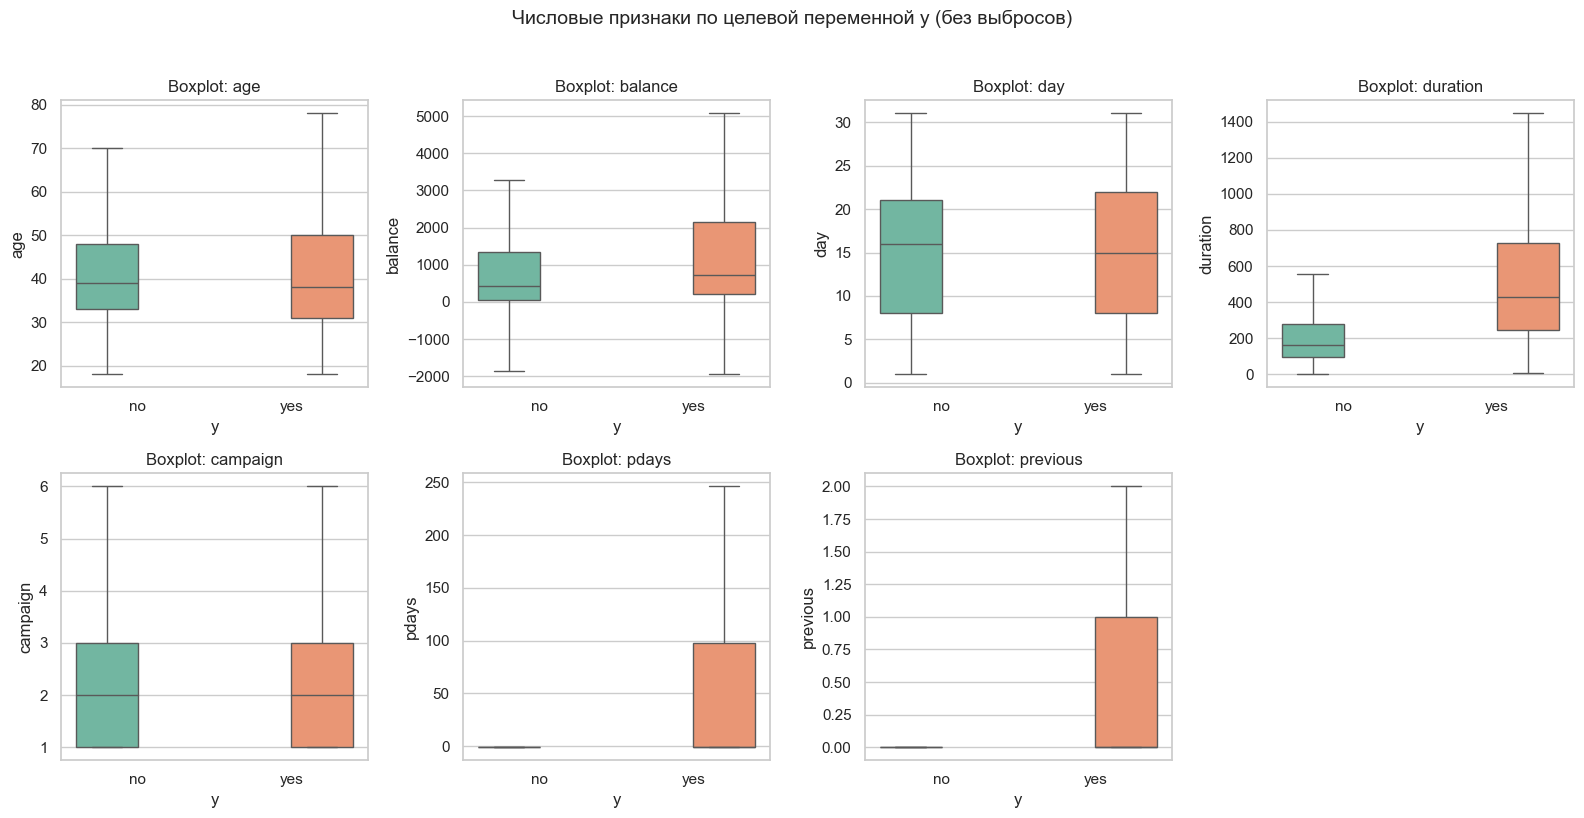

In [59]:
# без выбросов, иначе ось слипается
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=df, x='y', y=col, hue='y', ax=ax,
        palette='Set2', legend=False, showfliers=False,
    )
    ax.set_title(f'Boxplot: {col}')
    ax.set_xlabel('y')
    ax.set_ylabel(col)

axes[-1].axis('off')
plt.suptitle('Числовые признаки по целевой переменной y (без выбросов)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### Выводы по анализу

Классы распределены неравномерно: отказов существенно больше, чем согласий, поэтому основной метрикой выступает PR-AUC, а не доля верных ответов.

Наиболее выраженная связь с целевой переменной наблюдается у month, poutcome, contact, job и housing. Числовые распределения у классов в основном пересекаются; наибольшее различие даёт duration, который исключается из модели. У balance, campaign и previous наблюдаются длинные хвосты распределений, что учитывается при выборе способа масштабирования. Между числовыми признаками сильных линейных связей немного; заметнее всего корреляция pdays и previous. Значение pdays = -1 кодирует отсутствие предыдущего контакта, а не нулевой интервал в днях.


## 3. Подготовка данных

Пропусков в исходном наборе нет, заполнение не требуется.

При pdays = -1 формируется признак was_contacted_before и значение -1 заменяется на 0 в числовом поле. Категории unknown сохраняются как отдельные значения при кодировании признаков. Признак duration исключается из модели во избежание утечки информации.

Порог для любой фильтрации и параметры масштабирования обучаются только на тренировочных данных после разделения выборок, иначе проверочная и тестовая выборки будут участвовать в переобучении модели.

Целевая переменная преобразуется в числовой вид: yes соответствует 1, no соответствует 0.


In [60]:
DROP_COLS = ['duration']
CAT_COLS = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'poutcome',
]
BASE_NUM_COLS = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


def prepare_features(df_in: pd.DataFrame, use_was_contacted: bool = True) -> pd.DataFrame:
    data = df_in.drop(columns=DROP_COLS, errors='ignore').copy()
    if use_was_contacted:
        data['was_contacted_before'] = (data['pdays'] != -1).astype(int)
    data.loc[data['pdays'] == -1, 'pdays'] = 0
    data['y_bin'] = (data['y'] == 'yes').astype(int)
    return data


df_prepared = prepare_features(df)
print(f'После подготовки: {df_prepared.shape[0]} строк, {df_prepared.shape[1]} колонок')
print(f'Доля согласий: {df_prepared["y_bin"].mean():.1%}')
print(f'Доля клиентов с прошлыми контактами: {(df_prepared["was_contacted_before"] == 1).mean():.1%}')
df_prepared[CAT_COLS + BASE_NUM_COLS + ['was_contacted_before', 'y_bin']].head()


После подготовки: 45211 строк, 18 колонок
Доля согласий: 11.7%
Доля клиентов с прошлыми контактами: 18.3%


,job,marital,education,default,housing,loan,contact,month,poutcome,age,balance,day,campaign,pdays,previous,was_contacted_before,y_bin
0,management,married,tertiary,no,yes,no,unknown,may,unknown,58,2143,5,1,0,0,0,0
1,technician,single,secondary,no,yes,no,unknown,may,unknown,44,29,5,1,0,0,0,0
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,33,2,5,1,0,0,0,0
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,47,1506,5,1,0,0,0,0
4,unknown,single,unknown,no,no,no,unknown,may,unknown,33,1,5,1,0,0,0,0


### Сравнение вариантов подготовки

На проверочной выборке сравниваются комбинации способа масштабирования и признака was_contacted_before по метрике PR-AUC. Тестовая выборка на этом этапе не используется.


In [61]:
def temporal_split(data: pd.DataFrame, train_frac=0.6, val_frac=0.2):
    n = len(data)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return data.iloc[:train_end], data.iloc[train_end:val_end], data.iloc[val_end:]


def feature_lists(use_was_contacted: bool):
    cat = CAT_COLS.copy()
    num = BASE_NUM_COLS.copy()
    if use_was_contacted:
        num = num + ['was_contacted_before']
    return cat, num


def quick_logreg_score(scaler, use_was_contacted=True):
    data = prepare_features(df, use_was_contacted=use_was_contacted)
    train_df, val_df, _ = temporal_split(data)

    cat_cols, num_cols = feature_lists(use_was_contacted)
    feature_cols = cat_cols + num_cols

    X_train = train_df[feature_cols]
    y_train = train_df['y_bin']
    X_val = val_df[feature_cols]
    y_val = val_df['y_bin']

    pre = ColumnTransformer([
        ('num', scaler, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])
    pipe = Pipeline([
        ('pre', pre),
        ('model', LogisticRegression(
            max_iter=10_000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, proba)


ablation = pd.DataFrame([
    {
        'scaler': 'StandardScaler',
        'was_contacted_before': 'нет',
        'PR-AUC (val)': quick_logreg_score(StandardScaler(), False),
    },
    {
        'scaler': 'RobustScaler',
        'was_contacted_before': 'нет',
        'PR-AUC (val)': quick_logreg_score(RobustScaler(), False),
    },
    {
        'scaler': 'StandardScaler',
        'was_contacted_before': 'да',
        'PR-AUC (val)': quick_logreg_score(StandardScaler(), True),
    },
    {
        'scaler': 'RobustScaler',
        'was_contacted_before': 'да',
        'PR-AUC (val)': quick_logreg_score(RobustScaler(), True),
    },
])
ablation = ablation.sort_values('PR-AUC (val)', ascending=False).reset_index(drop=True)
ablation


,scaler,was_contacted_before,PR-AUC (val)
0,StandardScaler,да,0.162743
1,RobustScaler,да,0.162388
2,StandardScaler,нет,0.162284
3,RobustScaler,нет,0.162111


По таблице выбирается лучшая комбинация масштабирования и признака was_contacted_before. Отдельный столбец для was_contacted_before показывает вклад только этого признака при прочих равных условиях подготовки данных.


## 4. Разделение данных

Записи упорядочены по дате, поэтому разделение выполняется по времени, а не случайным образом:

- тренировочная выборка — первые 60 процентов записей;
- проверочная выборка — следующие 20 процентов;
- тестовая выборка — последние 20 процентов.

Проверочная выборка применяется для выбора параметров подготовки и модели. Тестовая выборка используется однократно для финальной оценки.


In [62]:
best_row = ablation.iloc[0]
USE_WAS_CONTACTED = best_row['was_contacted_before'] == 'да'
CHOSEN_SCALER_NAME = best_row['scaler']

print(f'Выбранный способ масштабирования: {CHOSEN_SCALER_NAME}')
print(f'Используем признак was_contacted_before: {USE_WAS_CONTACTED}')
print(f'PR-AUC на проверочной выборке: {best_row["PR-AUC (val)"]:.4f}')

model_df = prepare_features(df, use_was_contacted=USE_WAS_CONTACTED)
CAT_FEATURES, NUM_FEATURES = feature_lists(USE_WAS_CONTACTED)
FEATURE_COLUMNS = CAT_FEATURES + NUM_FEATURES

train_df, val_df, test_df = temporal_split(model_df)

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df['y_bin']
X_val = val_df[FEATURE_COLUMNS]
y_val = val_df['y_bin']
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df['y_bin']

split_labels = {'train': 'обучение', 'val': 'проверка', 'test': 'тест'}
for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(
        f'{split_labels[name]:9} | строк={len(part):5} | '
        f"согласий={part['y_bin'].mean():.1%} | month={part['month'].iloc[0]}..{part['month'].iloc[-1]}"
    )
print(f'Числовых признаков: {len(NUM_FEATURES)}, категориальных: {len(CAT_FEATURES)}')


Выбранный способ масштабирования: StandardScaler
Используем признак was_contacted_before: True
PR-AUC на проверочной выборке: 0.1627
обучение  | строк=27126 | согласий=5.0% | month=may..nov
проверка  | строк= 9042 | согласий=11.8% | month=nov..may
тест      | строк= 9043 | согласий=31.6% | month=may..nov
Числовых признаков: 7, категориальных: 9


## 5. Обучение моделей

Сравниваются четыре варианта логистической регрессии:

- без регуляризации;
- с L2-регуляризацией и подбором параметра C на тренировочной выборке;
- с L1-регуляризацией;
- с ElasticNet-регуляризацией и подбором C и l1_ratio.

Во всех моделях задаётся балансировка классов. Предобработка данных и модель объединяются в единый конвейер, чтобы параметры масштабирования обучались только на тренировочных данных.


In [63]:
def build_preprocessor():
    scaler = RobustScaler() if CHOSEN_SCALER_NAME == 'RobustScaler' else StandardScaler()
    return ColumnTransformer([
        ('num', scaler, NUM_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
    ])


def collect_metrics(model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(y, proba),
        'pr_auc': average_precision_score(y, proba),
        'precision': precision_score(y, pred, zero_division=0),
        'recall': recall_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
    }


def metrics_table(model, splits, threshold=0.5):
    rows = []
    for split_name, (X_split, y_split) in splits.items():
        metrics = collect_metrics(model, X_split, y_split, threshold=threshold)
        metrics['split'] = split_name
        rows.append(metrics)
    return pd.DataFrame(rows).set_index('split')[['roc_auc', 'pr_auc', 'precision', 'recall', 'f1']]


def evaluate_model(name, model, param_grid=None):
    pipe = Pipeline([
        ('pre', build_preprocessor()),
        ('model', model),
    ])
    if param_grid is None:
        pipe.fit(X_train, y_train)
        best_pipe = pipe
        best_params = {}
    else:
        grid = GridSearchCV(
            pipe,
            param_grid=param_grid,
            scoring='average_precision',
            cv=3,
            n_jobs=-1,
        )
        grid.fit(X_train, y_train)
        best_pipe = grid.best_estimator_
        best_params = grid.best_params_

    val_metrics = collect_metrics(best_pipe, X_val, y_val)
    test_metrics = collect_metrics(best_pipe, X_test, y_test)
    return {
        'model': name,
        'best_params': best_params,
        'PR-AUC (val)': val_metrics['pr_auc'],
        'ROC-AUC (val)': val_metrics['roc_auc'],
        'F1 (val)': val_metrics['f1'],
        'PR-AUC (test)': test_metrics['pr_auc'],
        'ROC-AUC (test)': test_metrics['roc_auc'],
        'F1 (test)': test_metrics['f1'],
        'pipeline': best_pipe,
    }


splits = {
    'train': (X_train, y_train),
    'val': (X_val, y_val),
    'test': (X_test, y_test),
}


In [64]:
C_GRID = np.logspace(-3, 2, 8)

results = [
    evaluate_model(
        'LogReg (none)',
        LogisticRegression(
            penalty=None,
            solver='lbfgs',
            max_iter=10_000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        ),
    ),
    evaluate_model(
        'LogReg L2',
        LogisticRegression(
            penalty='l2',
            solver='lbfgs',
            max_iter=10_000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        ),
        param_grid={'model__C': C_GRID},
    ),
    evaluate_model(
        'LogReg L1',
        LogisticRegression(
            penalty='l1',
            solver='saga',
            max_iter=10_000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        ),
        param_grid={'model__C': C_GRID},
    ),
    evaluate_model(
        'LogReg ElasticNet',
        LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            max_iter=10_000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        ),
        param_grid={
            'model__C': C_GRID,
            'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        },
    ),
]

metrics_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('pipeline', 'best_params')} for r in results]
)
metrics_df = metrics_df.sort_values('PR-AUC (val)', ascending=False).reset_index(drop=True)
metrics_df


,model,PR-AUC (val),ROC-AUC (val),F1 (val),PR-AUC (test),ROC-AUC (test),F1 (test)
0,LogReg L2,0.167624,0.602332,0.235067,0.393614,0.599090,0.446516
1,LogReg (none),0.162959,0.621607,0.256162,0.442220,0.669264,0.524239
2,LogReg L1,0.117894,0.500000,0.000000,0.315824,0.500000,0.000000
3,LogReg ElasticNet,0.117894,0.500000,0.210922,0.315824,0.500000,0.480040


In [65]:
for r in results:
    print(f"{r['model']}: {r['best_params'] or '(параметры по умолчанию)'}")


LogReg (none): (параметры по умолчанию)
LogReg L2: {'model__C': np.float64(0.001)}
LogReg L1: {'model__C': np.float64(0.001)}
LogReg ElasticNet: {'model__C': np.float64(0.001), 'model__l1_ratio': 0.9}


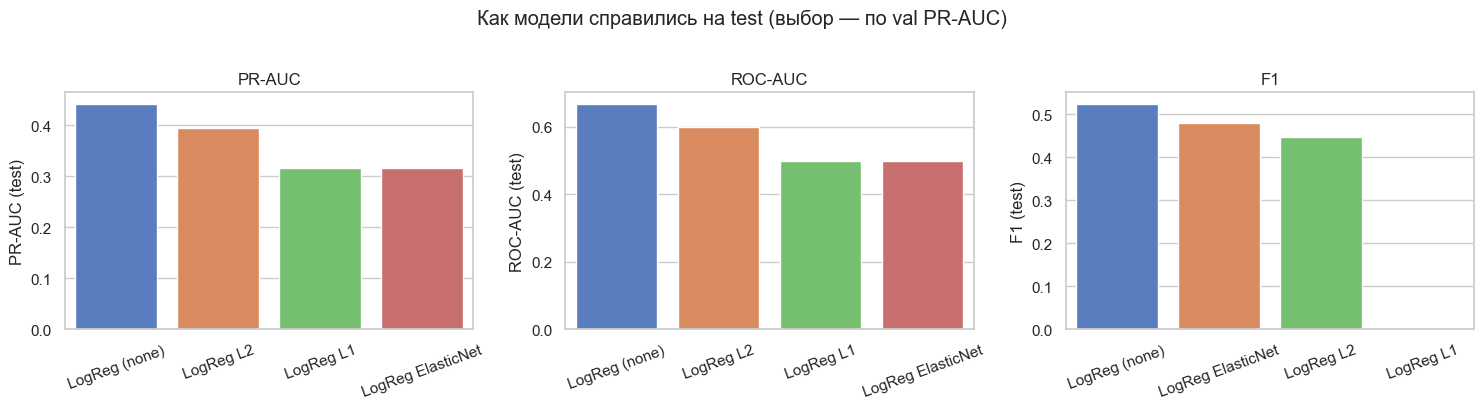

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = sns.color_palette('muted', n_colors=4)

for ax, metric, title in zip(
    axes,
    ['PR-AUC (test)', 'ROC-AUC (test)', 'F1 (test)'],
    ['PR-AUC', 'ROC-AUC', 'F1'],
):
    plot_df = metrics_df.sort_values(metric, ascending=False)
    sns.barplot(data=plot_df, x='model', y=metric, ax=ax, palette=colors)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Как модели справились на test (выбор — по val PR-AUC)', y=1.02)
plt.tight_layout()
plt.show()


Финальная модель по val PR-AUC: LogReg L2
PR-AUC на проверке: 0.168, на тесте: 0.394


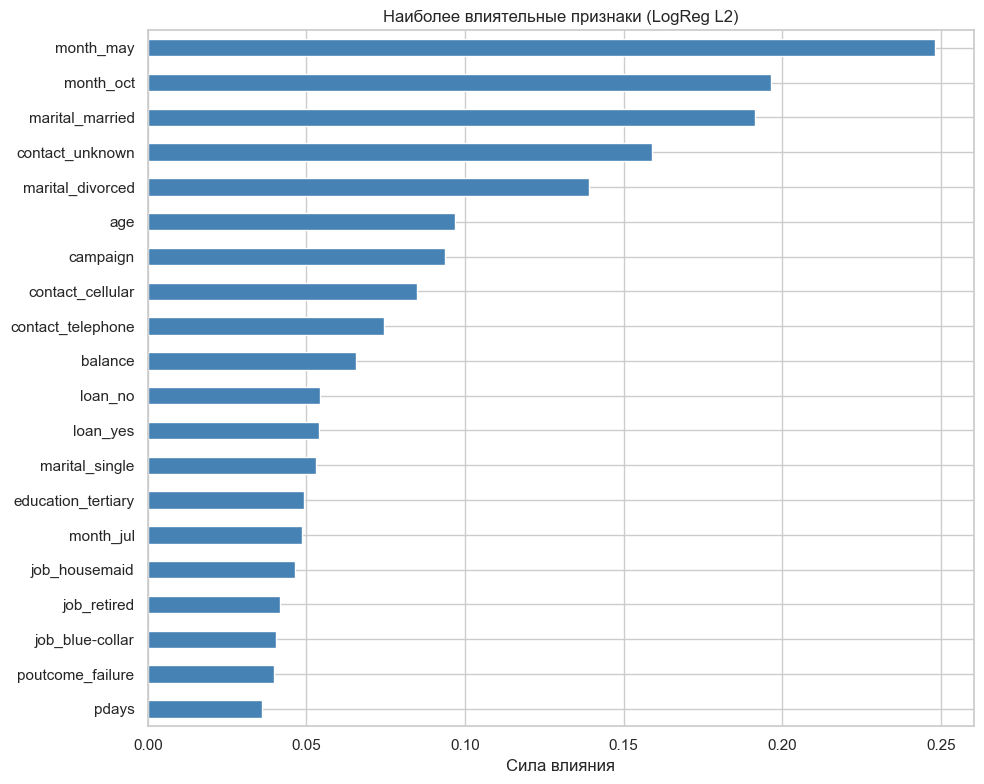

month_may             0.248047
month_oct             0.196540
marital_married       0.191568
contact_unknown       0.158894
marital_divorced      0.139103
age                   0.096808
campaign              0.093763
contact_cellular      0.084815
contact_telephone     0.074578
balance               0.065722
loan_no               0.054358
loan_yes              0.053859
marital_single        0.052964
education_tertiary    0.049289
month_jul             0.048471
dtype: float64

In [67]:
def get_feature_names(preprocessor):
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_FEATURES)
    return list(NUM_FEATURES) + list(cat_names)


def plot_feature_importance(pipeline, model_name, top_n=20):
    pre = pipeline.named_steps['pre']
    coefs = pipeline.named_steps['model'].coef_.ravel()
    feature_names = get_feature_names(pre)

    importance = pd.Series(np.abs(coefs), index=feature_names).sort_values(ascending=False)
    top = importance.head(top_n).sort_values()

    plt.figure(figsize=(10, 8))
    top.plot(kind='barh', color='steelblue')
    plt.title(f'Наиболее влиятельные признаки ({model_name})')
    plt.xlabel('Сила влияния')
    plt.tight_layout()
    plt.show()
    return importance


best_result = max(results, key=lambda r: r['PR-AUC (val)'])
final_model = best_result['pipeline']
final_name = best_result['model']
print(f'Финальная модель по val PR-AUC: {final_name}')
print(f"PR-AUC на проверке: {best_result['PR-AUC (val)']:.3f}, на тесте: {best_result['PR-AUC (test)']:.3f}")

importance = plot_feature_importance(final_model, final_name)
importance.head(15)


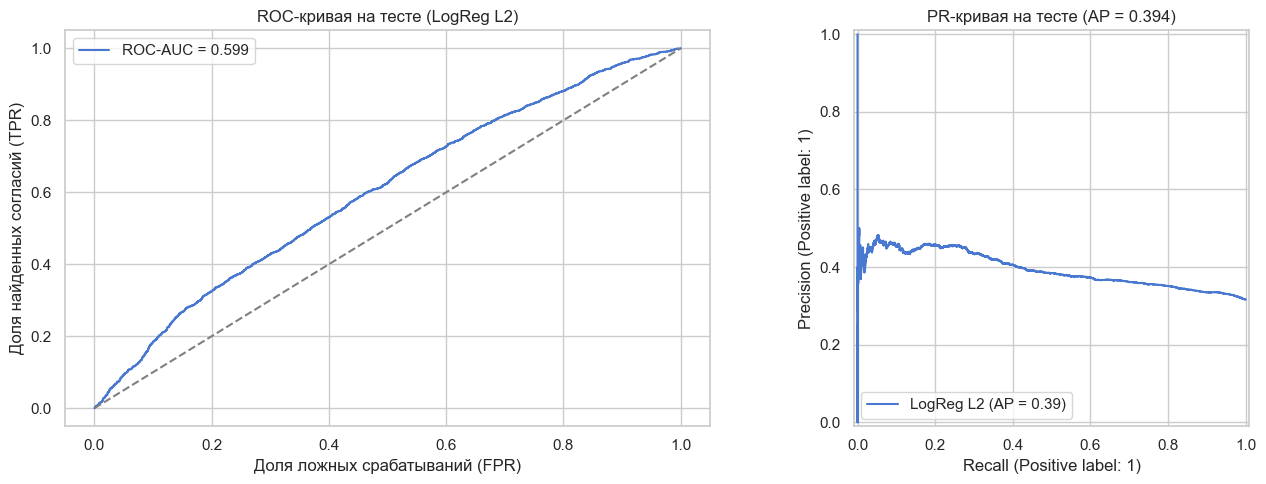

              precision    recall  f1-score   support

          no       0.74      0.59      0.65      6187
         yes       0.38      0.55      0.45      2856

    accuracy                           0.57      9043
   macro avg       0.56      0.57      0.55      9043
weighted avg       0.62      0.57      0.59      9043



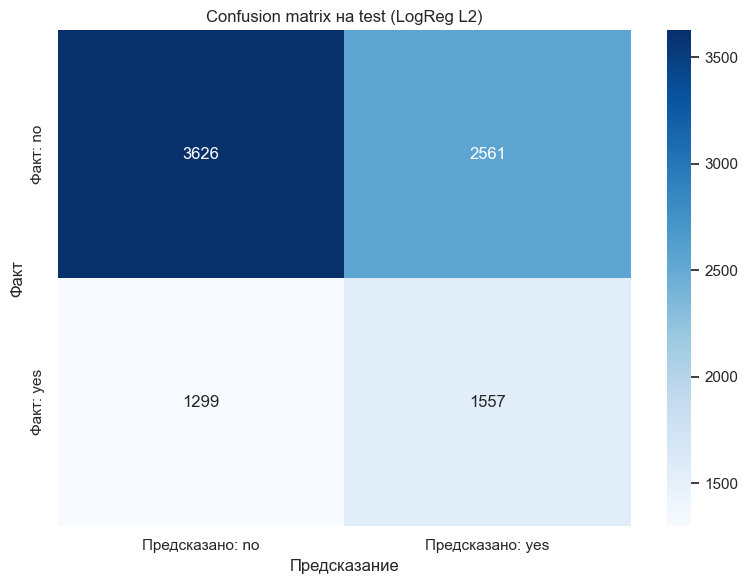

Метрики финальной модели:


,roc_auc,pr_auc,precision,recall,f1
split,,,,,
train,0.618312,0.076548,0.068241,0.577176,0.122051
val,0.602332,0.167624,0.141806,0.686679,0.235067
test,0.599090,0.393614,0.378096,0.545168,0.446516


In [68]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_test_proba):.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('Доля ложных срабатываний (FPR)')
axes[0].set_ylabel('Доля найденных согласий (TPR)')
axes[0].set_title(f'ROC-кривая на тесте ({final_name})')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, ax=axes[1], name=final_name)
axes[1].set_title(f'PR-кривая на тесте (AP = {average_precision_score(y_test, y_test_proba):.3f})')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_test_pred, target_names=['no', 'yes']))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['Предсказано: no', 'Предсказано: yes'],
    yticklabels=['Факт: no', 'Факт: yes'],
)
plt.xlabel('Предсказание')
plt.ylabel('Факт')
plt.title(f'Confusion matrix на test ({final_name})')
plt.tight_layout()
plt.show()

print('Метрики финальной модели:')
metrics_table(final_model, splits)


## 6. Контроль переобучения

Применяются следующие меры:

- разделение данных по времени, чтобы тестовая выборка содержала более поздние кампании;
- обучение преобразований признаков только на тренировочной выборке;
- выбор способа масштабирования и признаков по проверочной выборке без участия тестовой;
- регуляризация моделей и балансировка классов;
- подбор гиперпараметров на тренировочной выборке с кросс-валидацией, выбор модели по проверочной выборке.

Переобучение диагностируется по заметному разрыву метрик между тренировочной и проверочной или тестовой выборками.


In [69]:
overfit_check = metrics_table(final_model, splits)[['roc_auc', 'pr_auc', 'f1']]
train_test_gap = (
    overfit_check.loc['train', 'roc_auc'] - overfit_check.loc['test', 'roc_auc']
)
train_val_gap = (
    overfit_check.loc['train', 'roc_auc'] - overfit_check.loc['val', 'roc_auc']
)
print(f'Разрыв ROC-AUC (обучение − проверка): {train_val_gap:.3f}')
print(f'Разрыв ROC-AUC (обучение − тест): {train_test_gap:.3f}')
overfit_check


Разрыв ROC-AUC (обучение − проверка): 0.016
Разрыв ROC-AUC (обучение − тест): 0.019


,roc_auc,pr_auc,f1
split,,,
train,0.618312,0.076548,0.122051
val,0.602332,0.167624,0.235067
test,0.599090,0.393614,0.446516


## 7. Выводы

В работе построена модель, которая по данным о клиенте и параметрах обзвона оценивает вероятность согласия на срочный вклад. Длительность звонка в обучение не входит: эта информация появляется только после контакта и исказила бы оценку. Для корректной обработки pdays = -1 добавлен признак was_contacted_before. Способ масштабирования числовых признаков и состав признаков зафиксированы по результатам на проверочной выборке.

Среди четырёх вариантов логистической регрессии лучшим на проверочной выборке оказался вариант с L2-регуляризацией. На тестовой выборке PR-AUC составляет около 0.39. Это выше случайного уровня около 0.12 при доле согласий около 12 процентов в исходных данных и говорит о том, что модель умеет отличать более перспективных клиентов от менее перспективных.

При пороге 0.5 модель находит примерно 55 процентов реальных согласий, но среди тех, кого она помечает как согласившихся, верными оказываются около 38 процентов. Такая точность невысока: много ложных срабатываний. Это ожидаемо при дисбалансе классов и при том, что до звонка доступно мало информации о реакции клиента. На практике порог можно повысить: тогда среди выбранных для обзвона будет больше реальных согласий, но часть согласившихся клиентов будет пропущена. Разрыв ROC-AUC между обучением и тестом невелик, около 0.02, сильного переобучения не видно.

Наиболее сильно на прогноз влияют месяц контакта, семейное положение, канал связи, возраст и число звонков в кампании. Это согласуется с первичным анализом данных.

Практический смысл модели скорее в ранжировании клиентов, чем в жёстком ответе да или нет. Клиентов с более высокой оценённой вероятностью согласия можно обзванивать в первую очередь. Полностью предсказать исход контакта по доступным до звонка признакам нельзя, но упорядочить очередь обзвона модель помогает.
